In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.ndim

2

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
np.random.seed(42)

null_indices_tc = np.random.choice(df.index, size=150, replace=False)
df.loc[null_indices_tc, 'TotalCharges'] = np.nan

null_indices_tenure = np.random.choice(df.index, size=80, replace=False)
df.loc[null_indices_tenure, 'tenure'] = np.nan


duplicate_rows = df.sample(50, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)


inconsistent_indices = np.random.choice(df.index, size=100, replace=False)
df.loc[inconsistent_indices, 'Churn'] = df.loc[inconsistent_indices, 'Churn'].str.lower()

inconsistent_indices2 = np.random.choice(df.index, size=80, replace=False)
df.loc[inconsistent_indices2, 'Partner'] = df.loc[inconsistent_indices2, 'Partner'].str.upper()


string_indices = np.random.choice(df.index, size=30, replace=False)
df.loc[string_indices, 'tenure'] = 'unknown'

outlier_indices = np.random.choice(df.index, size=20, replace=False)
df.loc[outlier_indices, 'MonthlyCharges'] = np.random.choice([999, 1500, 2000], size=20)


df['random_noise'] = np.random.randint(0, 1000, size=len(df))


df.to_csv("telco_churn_messy.csv", index=False)

print("Messy dataset created!")
print(f"Shape: {df.shape}")
print(f"\nNull counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nChurn unique values: {df['Churn'].unique()}")
print(f"Partner unique values: {df['Partner'].unique()}")



Messy dataset created!
Shape: (7093, 22)

Null counts:
tenure           79
TotalCharges    200
dtype: int64

Churn unique values: ['No' 'Yes' 'no' 'yes']
Partner unique values: ['Yes' 'No' 'NO' 'YES']


/tmp/ipykernel_12787/4041095167.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[string_indices, 'tenure'] = 'unknown'


In [9]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,79
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df.shape)
print(df.drop_duplicates().shape)

(7093, 22)
(7093, 22)


In [12]:

print("Before:", df.shape)


duplicate_rows = df.sample(50, random_state=42).copy()


df = pd.concat([df, duplicate_rows], ignore_index=True)

print("After:", df.shape)
print("Duplicates found:", df.duplicated().sum())

Before: (7093, 22)
After: (7143, 22)
Duplicates found: 50


In [13]:
df.duplicated().sum()

np.int64(50)

In [14]:
df.to_csv("telco_churn_messy.csv", index=False)
print("✅ Saved! Shape:", df.shape)

✅ Saved! Shape: (7143, 22)


In [15]:
df.shape
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure               object
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
random_noise          int64
dtype: object


In [16]:
df.describe()

,SeniorCitizen,MonthlyCharges,random_noise
count,7143.000000,7143.000000,7143.000000
mean,0.162817,68.966702,496.902702
std,0.369224,85.380524,289.973768
min,0.000000,18.250000,0.000000
25%,0.000000,35.650000,245.000000
50%,0.000000,70.400000,497.000000
75%,0.000000,89.950000,749.000000
max,1.000000,2000.000000,999.000000


In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,random_noise
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,83
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,623
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,709
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,359
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,380


In [18]:
print(df['TotalCharges'].isnull().sum())
print(df['tenure'].isnull().sum())

204
80


In [19]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,80
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [20]:
df['Churn'].value_counts()

,count
Churn,
No,5156
Yes,1887
no,81
yes,19


In [21]:
df['Churn'] = df['Churn'].str.strip().str.capitalize()
print(df['Churn'].value_counts())

Churn
No     5237
Yes    1906
Name: count, dtype: int64


In [22]:
df['Partner'] = df['Partner'].str.strip().str.capitalize()
print(df['Partner'].value_counts())

Partner
No     3700
Yes    3443
Name: count, dtype: int64


In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)


float64


In [24]:
print(df['TotalCharges'].isnull().sum())

215


In [25]:
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
print(df['tenure'].dtype)


float64


In [26]:
print(df['tenure'].isnull().sum())

110


In [27]:
print(df.isnull().sum()[df.isnull().sum() > 0])

tenure          110
TotalCharges    215
dtype: int64


In [28]:
df['tenure'].value_counts()

,count
tenure,
1.0,616
72.0,366
2.0,239
3.0,197
4.0,176
...,...
59.0,58
39.0,56
44.0,52


In [29]:
df['tenure'].unique()

array([ 1., 34.,  2., 45.,  8., 22., 10., 28., 62., 13., 16., 58., 49.,
       25., 69., 52., 71., 21., 12., 30., 47., 72., 17., 27.,  5., 46.,
       11., 70., 63., 43., 15., 60., 18., 66.,  9.,  3., 31., 50., 64.,
       56.,  7., 42., 35., 48., 29., 65., 38., 68., 32., 55., 37., 36.,
       41.,  6.,  4., 33., nan, 67., 23., 57., 61., 14., 20., 53., 40.,
       59., 24., 44., 19., 54., 51., 26.,  0., 39.])

In [30]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
20.20,11
19.75,9
19.90,8
20.05,8
19.65,8
...,...
1263.90,1
2447.45,1
1140.05,1


In [31]:
df['tenure'] = df['tenure'].fillna(df['tenure'].median())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [32]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (7143, 22)
After: (7093, 22)


In [33]:
df = df.drop(columns=['random_noise'])
print(df.shape)

(7093, 21)


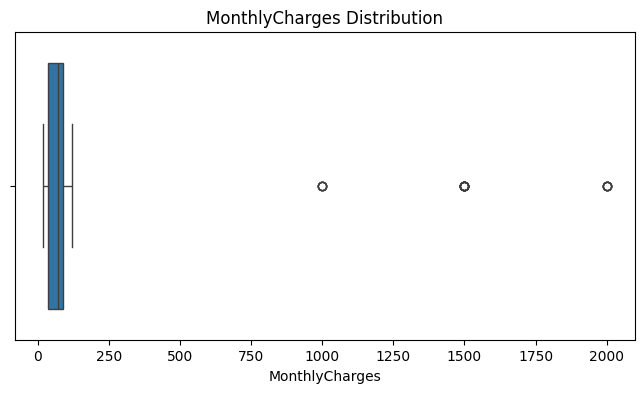

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df['MonthlyCharges'])
plt.title('MonthlyCharges Distribution')
plt.show()

In [35]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outliers found: {((df['MonthlyCharges'] < lower) | (df['MonthlyCharges'] > upper)).sum()}")

Q1: 35.65, Q3: 89.95, IQR: 54.300000000000004
Lower bound: -45.800000000000004, Upper bound: 171.4
Outliers found: 20


In [36]:
median_mc = df['MonthlyCharges'].median()
df['MonthlyCharges'] = df['MonthlyCharges'].apply(
    lambda x: median_mc if x > upper else x
)

print("Outliers remaining:", ((df['MonthlyCharges'] > upper)).sum())

Outliers remaining: 0


In [37]:
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("MonthlyCharges max:", df['MonthlyCharges'].max())
print("Churn values:", df['Churn'].unique())
print("Partner values:", df['Partner'].unique())

Shape: (7093, 21)
Nulls: 0
Duplicates: 49
MonthlyCharges max: 118.75
Churn values: ['No' 'Yes']
Partner values: ['Yes' 'No']


In [38]:
df = df.drop_duplicates()
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (7044, 21)
Duplicates: 0


In [39]:
df.to_csv("telco_churn_cleaned.csv", index=False)
print("Cleaned dataset saved!")

Cleaned dataset saved!


/tmp/ipykernel_12787/1363576992.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


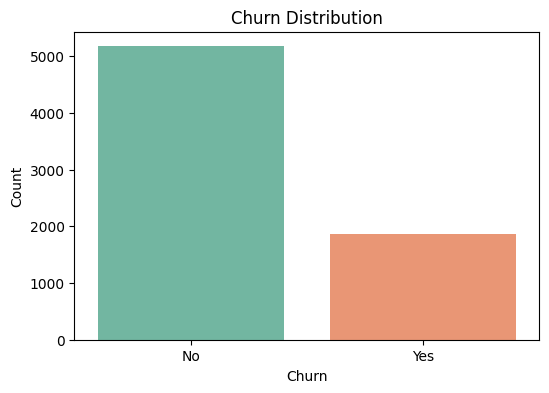

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

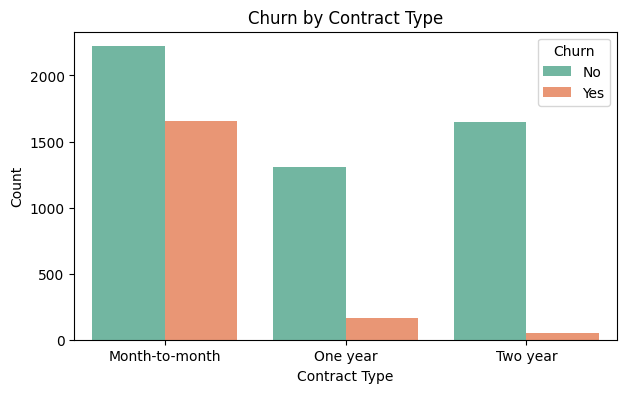

In [41]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

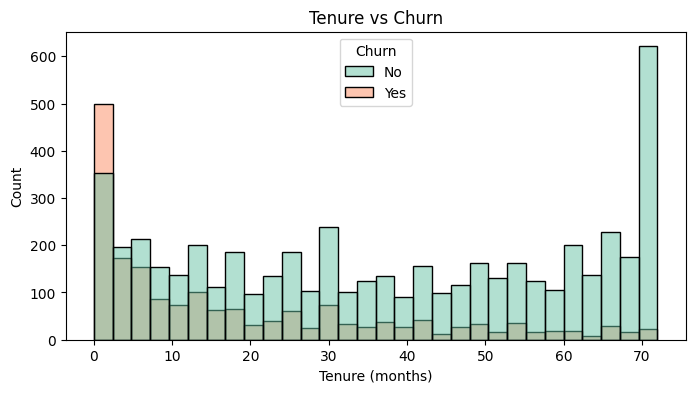

In [42]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_12787/2626357673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


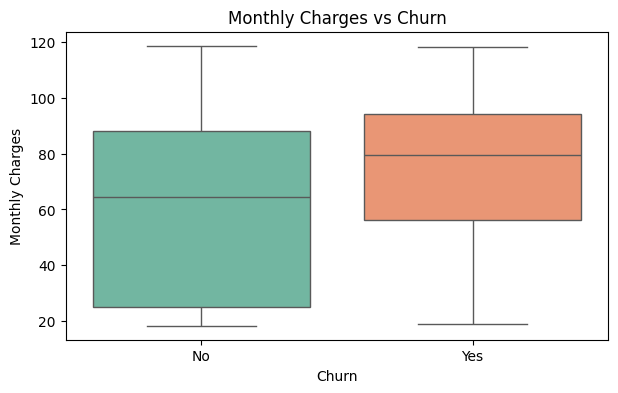

In [43]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

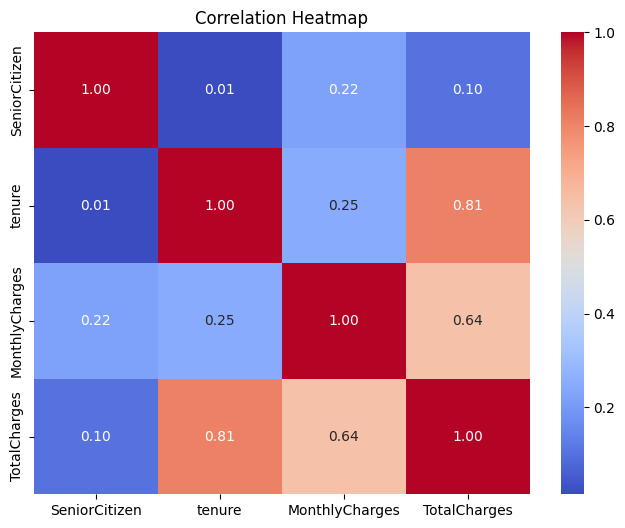

In [44]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [45]:
print(numeric_df.corr())

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.014894        0.220205      0.101180
tenure               0.014894  1.000000        0.245884      0.810087
MonthlyCharges       0.220205  0.245884        1.000000      0.641979
TotalCharges         0.101180  0.810087        0.641979      1.000000


In [46]:
df = df.drop(columns=['customerID', 'TotalCharges'])
print(df.shape)

(7044, 19)


In [47]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1870
Name: count, dtype: int64


In [48]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)
print("Total categorical columns:", len(categorical_cols))

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total categorical columns: 15


In [49]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} — {df[col].unique()}")

gender: 2 — ['Female' 'Male']
Partner: 2 — ['Yes' 'No']
Dependents: 2 — ['No' 'Yes']
PhoneService: 2 — ['No' 'Yes']
MultipleLines: 3 — ['No phone service' 'No' 'Yes']
InternetService: 3 — ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 — ['No' 'Yes' 'No internet service']
OnlineBackup: 3 — ['Yes' 'No' 'No internet service']
DeviceProtection: 3 — ['No' 'Yes' 'No internet service']
TechSupport: 3 — ['No' 'Yes' 'No internet service']
StreamingTV: 3 — ['No' 'Yes' 'No internet service']
StreamingMovies: 3 — ['No' 'Yes' 'No internet service']
Contract: 3 — ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 — ['Yes' 'No']
PaymentMethod: 4 — ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print(df[binary_cols].head())

   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1
3       1        0           0             0                 0
4       0        0           0             1                 1


In [51]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)
print(df.columns.tolist())

(7044, 30)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [52]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7044, 29)
y shape: (7044,)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5635, 29)
X_test: (1409, 29)
y_train: (5635,)
y_test: (1409,)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")
print("X_train mean (should be ~0):", X_train.mean().round(2))
print("X_train std (should be ~1):", X_train.std().round(2))

Scaling done!
X_train mean (should be ~0): -0.0
X_train std (should be ~1): 1.0


In [55]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1496}
After SMOTE: {1: 4139, 0: 4139}


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}


results = {}
for name, model in models.items():

    model.fit(X_train_sm, y_train_sm)


    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    results[name] = {
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1': report['1']['f1-score'],
        'AUC': auc
    }
    print(f"✅ {name} done!")

print("\nAll models trained!")

✅ Logistic Regression done!
✅ Random Forest done!
✅ XGBoost done!

All models trained!


In [57]:
import pandas as pd

results_df = pd.DataFrame(results).T.round(3)
print(results_df)

                     Accuracy  Precision  Recall     F1    AUC
Logistic Regression     0.746      0.514   0.775  0.618  0.840
Random Forest           0.777      0.579   0.586  0.582  0.818
XGBoost                 0.773      0.571   0.583  0.577  0.816


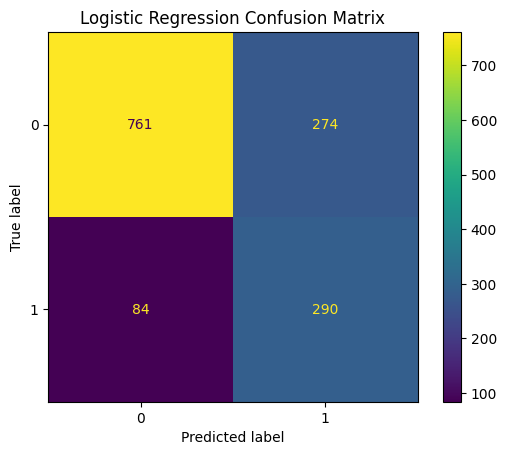

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

lr_model = models['Logistic Regression']
y_pred_lr = lr_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [59]:
import shap
print(shap.__version__)

0.51.0


In [61]:
explainer = shap.LinearExplainer(lr_model, X_train_sm)
shap_values = explainer.shap_values(X_test)

In [62]:
print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

SHAP values shape: (1409, 29)
X_test shape: (1409, 29)


/tmp/ipykernel_12787/2968537398.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test,


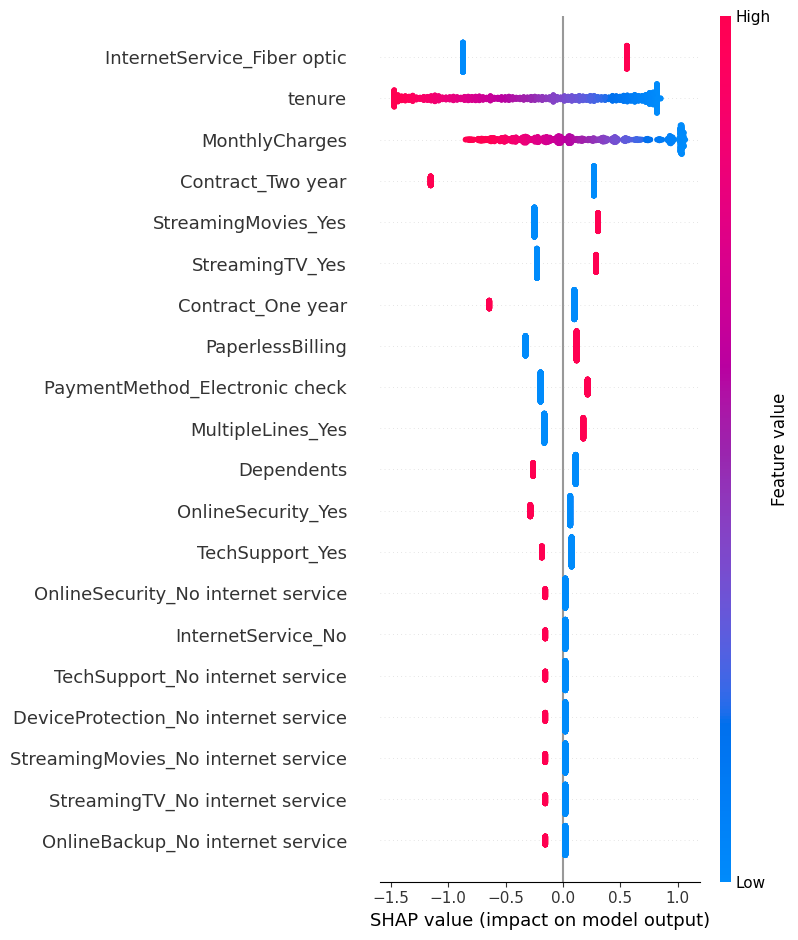

In [63]:
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist())

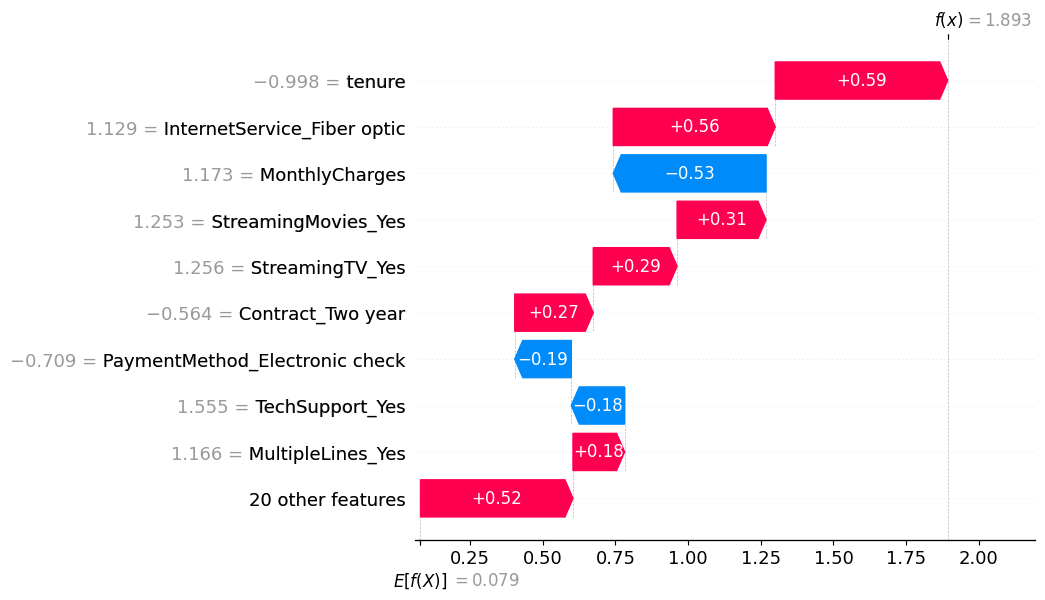

In [65]:

churn_indices = np.where(y_pred_lr == 1)[0]
customer_idx = churn_indices[0]


shap_explanation = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=X_test[customer_idx],
    feature_names=X.columns.tolist()
)

shap.plots.waterfall(shap_explanation, max_display=10)

In [66]:

X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_df['Actual_Churn'] = y_test.values
X_test_df['Predicted_Churn'] = y_pred_lr
X_test_df['Churn_Probability'] = lr_model.predict_proba(X_test)[:,1].round(3)

# Export
X_test_df.to_csv("churn_predictions.csv", index=False)
print("✅ Exported!", X_test_df.shape)

✅ Exported! (1409, 32)


In [67]:

shap_importance = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

shap_importance.to_csv("shap_importance.csv", index=False)
print("✅ SHAP importance exported!")
print(shap_importance.head(10))

✅ SHAP importance exported!
                          Feature  SHAP_Importance
0     InternetService_Fiber optic         0.732814
1                          tenure         0.687688
2                  MonthlyCharges         0.498702
3               Contract_Two year         0.479103
4             StreamingMovies_Yes         0.270372
5                 StreamingTV_Yes         0.249477
6               Contract_One year         0.215803
7                PaperlessBilling         0.202746
8  PaymentMethod_Electronic check         0.201655
9               MultipleLines_Yes         0.168414


In [68]:

df_original = pd.read_csv("telco_churn_cleaned.csv")
df_original['Predicted_Churn'] = None

df_original_test = df_original.iloc[y_test.index]
df_original_test = df_original_test.copy()
df_original_test['Predicted_Churn'] = y_pred_lr
df_original_test['Churn_Probability'] = lr_model.predict_proba(X_test)[:,1].round(3)

df_original_test.to_csv("churn_dashboard.csv", index=False)
print("✅ Exported!", df_original_test.shape)

✅ Exported! (1409, 23)
